# Preparation of training and test scenario

To be prepred:
- TRAIN 5000 requests, 10 taken in each step
- TEST x3 1000 requests, 10 taken in each step

Test for the borken pipe - for each 10 steps queues (not all together)

In [1]:
import random
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Environment.distributed_app import *

In [2]:
def test_for_broken_pipe(queue_array):
    
    # max storage capacity
    machines = 15 * ['vm1'] + 10 * ['vm2'] + 3 * ['vm3']
    random.shuffle(machines)
    
    resources = {'vm1': [8,8],
                 'vm2': [16, 10],
                 'vm3': [32, 24]}
    
    distributed_app = DistributedApp(queue_array=queue_array,
                                    alpha=0.5,
                                    beta=0.5,
                                    machines=machines,
                                    resources=resources)

    time_per_step = distributed_app._perform_all_requests()
    time_per_step 
    return time_per_step

def test_all_the_cuts(queue):
    cnt = 0
    for request in queue:
        if (cnt > 0) &  (cnt % 10 == 0):
            test_list = queue[cnt-10: cnt]
            test_for_broken_pipe(test_list)
        cnt+=1
    print("All tests passed.")

def save_scenario_to_txt(queue_array, file_name):
    file = "Environment/Scenarios/" + str(file_name) + ".txt"
    with open(file, "w") as output:
        for _, el in enumerate(queue_array):
            output.write(str(el)+"\n")
            
            
def apply_change(start, change, mode, max_value):
    
        def delete(start, change):
            if start - change < 1:
                return 2
            else:
                return start - change
            
        def add(start, change):
            if start + change > max_value:
                return max_value - 1
            else:
                return start + change
            
        if mode == 'increasing':
            return add(start, change)
            
        elif mode == 'descresing':
            return delete(start, change)
            
        elif mode == 'unstable':
            random_pick = random.randint(0, 1)
            if random_pick == 0:
                return delete(start, change)
            else:
                return add(start, change)
        else:
            print("There is no mode as given.")
            return -1


def generate_workload(start_initial, no_of_request, randomness_level,  mode, max_value=20, cont=10):
    """
    Parameters:
        initial(int) - initial state of the queue
        no_of_request(int) - how many requests should be generated
        mode - "increasing" / "descresing" / "unstable"
    """
    return_list = []
    for i in range(1, no_of_request+1):
        # take random number
        change = random.randint(0, randomness_level)
        # apply action
        if i ==1:
            start = start_initial
        else:
            start = int(return_list[-1])
        request = apply_change(start, change, mode, max_value)
        return_list += [request]*10
    
    return return_list

def vizualize_workload(queue, color='blue'):
    time_steps = list(range(1, len(queue)+1))
    workloads = pd.DataFrame({'Train workload': queue,
                              'Time': time_steps})

    plt.figure(figsize=(15,6))
    sns.lineplot(y='Train workload', x='Time', data=workloads, color=color)
    plt.ylabel('Workload')

Training scenario - unstable workload 

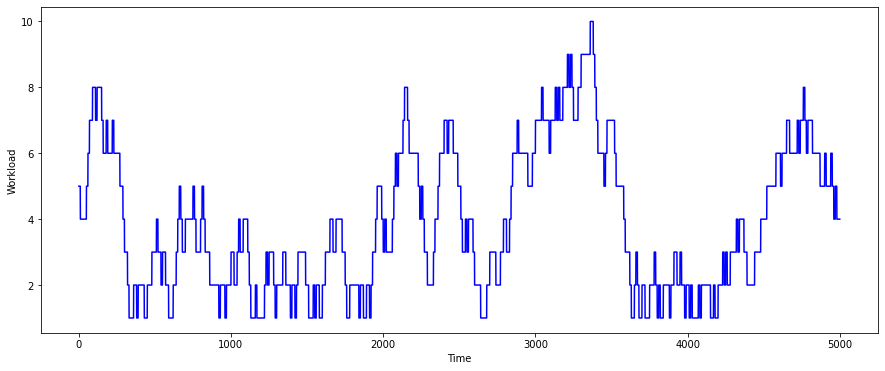

In [101]:
queue_array_train = generate_workload(5, 500, 1,  'unstable')
vizualize_workload(queue_array_train, color='blue')

Test for broken pipe

In [120]:
test_all_the_cuts(queue_array_train)

In [114]:
save_scenario_to_txt(queue_array_train, "train")

Testing scenarios

Scenario 1:  1000


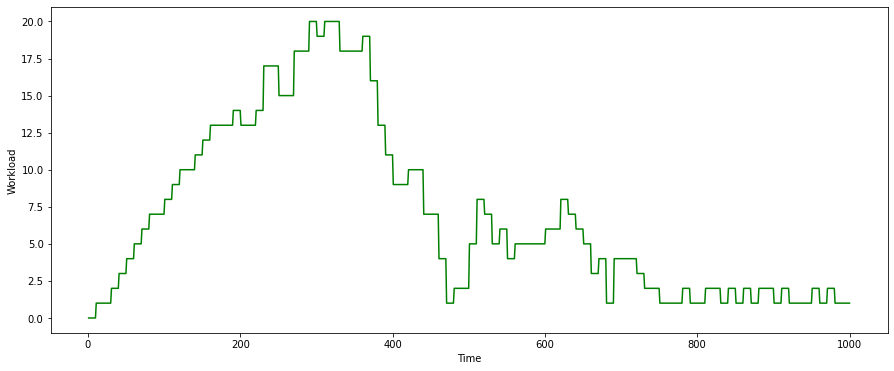

In [104]:
# scenario 1 - unstable workload 
cont1 = generate_workload(0, 20, 1,  'increasing')
cont2 = generate_workload(cont1[-1], 50, 3,  'unstable')
cont3 = generate_workload(cont2[-1], 30, 1,  'descresing')
queue_array_1 = list(itertools.chain(cont1, cont2, cont3))
print("Scenario 1: ", len(queue_array_1))
vizualize_workload(queue_array_1, color='green')

Scenario 2:  1000


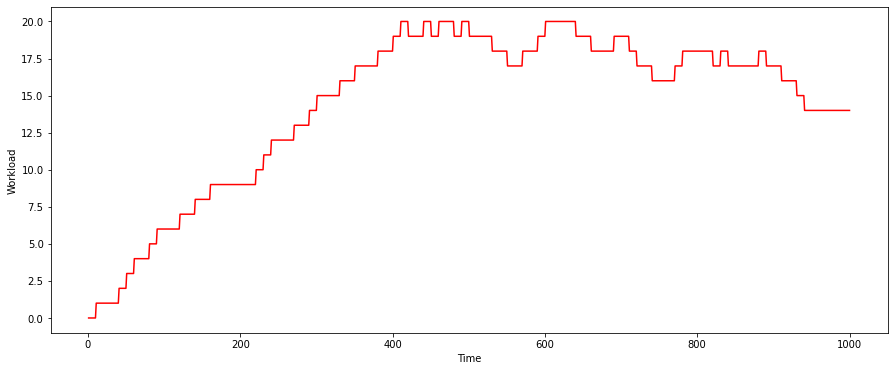

In [108]:
# scenario 2 - high workload
cont1 = generate_workload(0, 50, 1,  'increasing')
cont2 = generate_workload(cont1[-1], 50, 1,  'unstable')
queue_array_2 = list(itertools.chain(cont1, cont2))
print("Scenario 2: ", len(queue_array_2))
vizualize_workload(queue_array_2, color='red')

Scenario 3:  1000


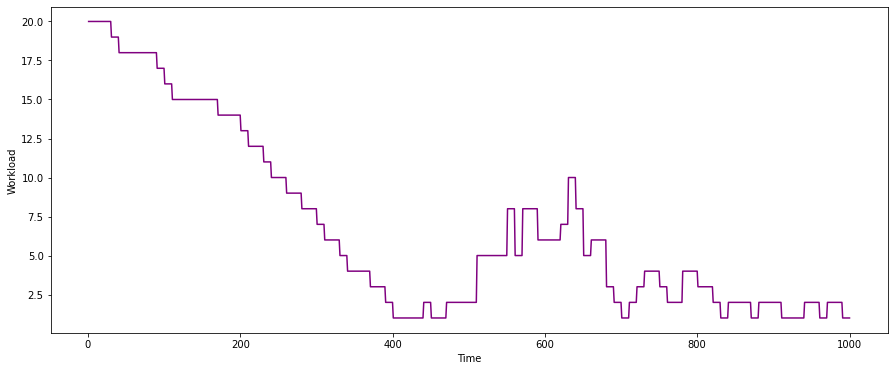

In [13]:
# scenario 3 - low workload
cont1 = generate_workload(20, 50, 1,  'descresing')
cont2 = generate_workload(cont1[-1], 30, 3,  'unstable')
cont3 = generate_workload(cont2[-1], 20, 1,  'descresing')
queue_array_3 = list(itertools.chain(cont1, cont2, cont3))
print("Scenario 3: ", len(queue_array_3))
vizualize_workload(queue_array_3, color='purple')

Scenario 4:  1000


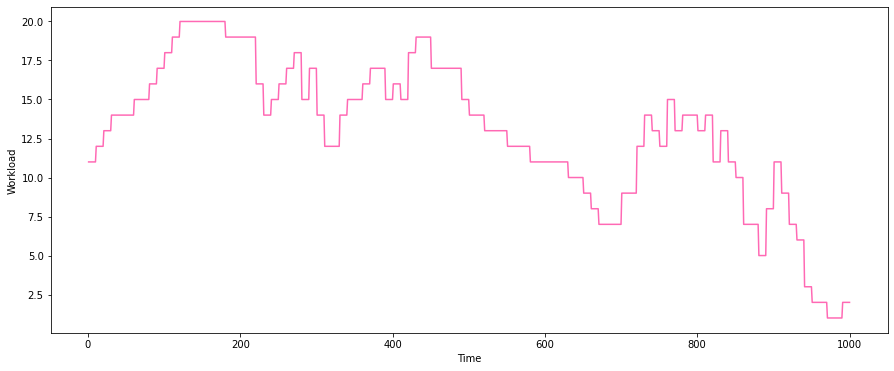

In [21]:
# scenario 4 
cont1 = generate_workload(10, 20, 1,  'increasing')
cont2 = generate_workload(cont1[-1], 30, 3,  'unstable')
cont3 = generate_workload(cont2[-1], 20, 1,  'descresing')
cont4 = generate_workload(cont3[-1], 30, 3,  'unstable')
queue_array_4 = list(itertools.chain(cont1, cont2, cont3, cont4))
print("Scenario 4: ", len(queue_array_4))
vizualize_workload(queue_array_4, color='hotpink')

Scenario 5:  1000


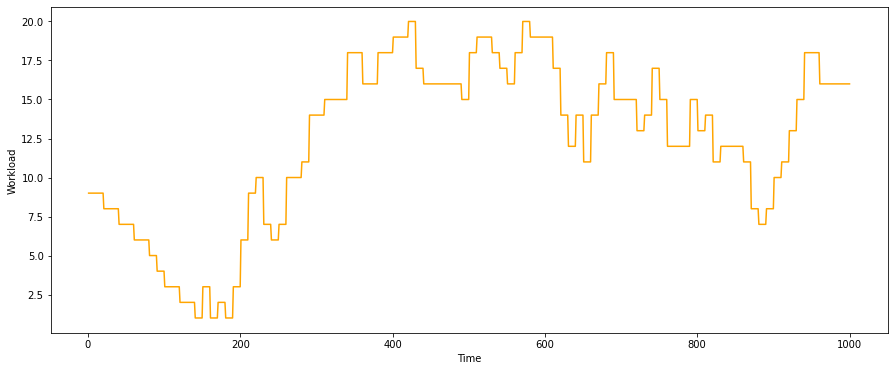

In [25]:
# scenario 5 
cont1 = generate_workload(10, 10, 1,  'descresing')
cont2 = generate_workload(cont1[-1], 90, 3,  'unstable')
queue_array_5 = list(itertools.chain(cont1, cont2))
print("Scenario 5: ", len(queue_array_5))
vizualize_workload(queue_array_5, color='orange')

Tests for broken pipeline

In [117]:
test_all_the_cuts(queue_array_1)

In [118]:
test_all_the_cuts(queue_array_2)

In [119]:
test_all_the_cuts(queue_array_3)

In [ ]:
test_all_the_cuts(queue_array_4)

In [ ]:
test_all_the_cuts(queue_array_5)

In [26]:
save_scenario_to_txt(queue_array_1, "test_scenario_1")
save_scenario_to_txt(queue_array_2, "test_scenario_2")
save_scenario_to_txt(queue_array_3, "test_scenario_3")
save_scenario_to_txt(queue_array_4, "test_scenario_4")
save_scenario_to_txt(queue_array_5, "test_scenario_5")

NameError: name 'queue_array_1' is not defined